# Experiment 17 EDA 08/04/2026
### Name : Tanmay Agarwal
### PRN : 25070123158
### Batch : EnTC A3
### Title: Exploring Statistical and Specialized Data Visualization Techniques

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

In [2]:
np.random.seed(10000000)
df = pd.DataFrame({
    'Category': ['A','B','C','D','E'],
    'Values': [0,70,30,90,60],
    'Sales': np.random.randint(100,500,5),
    'Profit': np.random.randint(10,100,5)
})

df.head()

,Category,Values,Sales,Profit
0,A,0,167,70
1,B,70,444,97
2,C,30,200,91
3,D,90,296,82
4,E,60,449,17


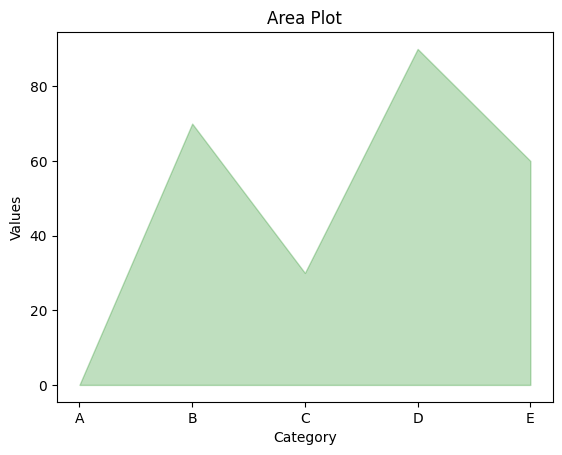

In [3]:
#1 Area Plot
plt.figure()
plt.fill_between(df['Category'],df['Values'],color='green',alpha=0.25)
plt.xlabel('Category')
plt.title("Area Plot")
plt.ylabel('Values')
plt.show()

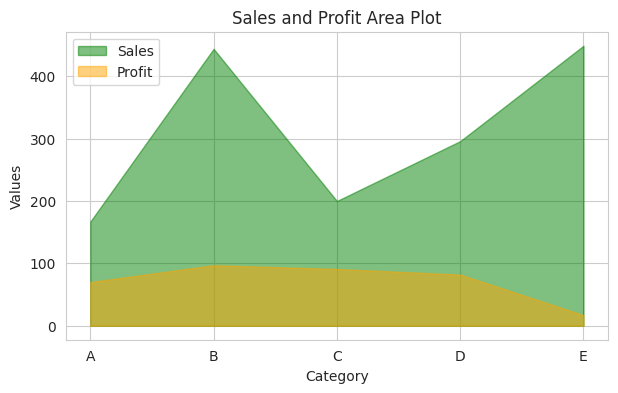

In [4]:
sns.set_style("whitegrid") # Apply seaborn style
plt.figure(figsize=(7,4))
plt.fill_between(df['Category'],df['Sales'],color='green',alpha=0.5,label='Sales')
plt.fill_between(df['Category'],df['Profit'],color = 'orange',alpha = 0.5,label='Profit')
plt.xlabel('Category')
plt.title("Sales and Profit Area Plot")
plt.ylabel('Values')
plt.legend()
plt.show()

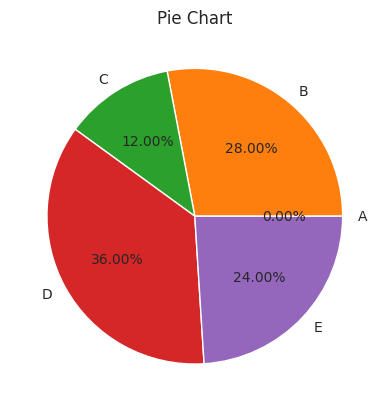

In [5]:
#2. Pie Chart

plt.figure()
plt.pie(df['Values'], labels=df['Category'], autopct='%1.2f%%')
plt.title("Pie Chart")
plt.show()

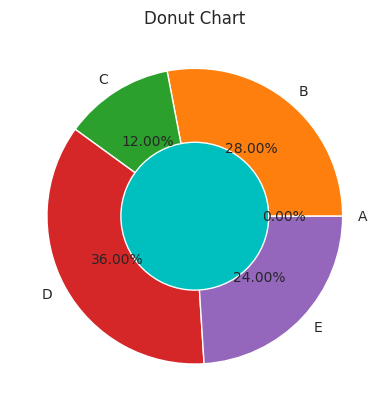

In [6]:
#3 Donut Chart
plt.figure()
plt.pie(df['Values'],labels=df['Category'],autopct='%1.2f%%')
centre_circle = plt.Circle((0,0),0.50,fc='c')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)
plt.title("Donut Chart")
plt.show()

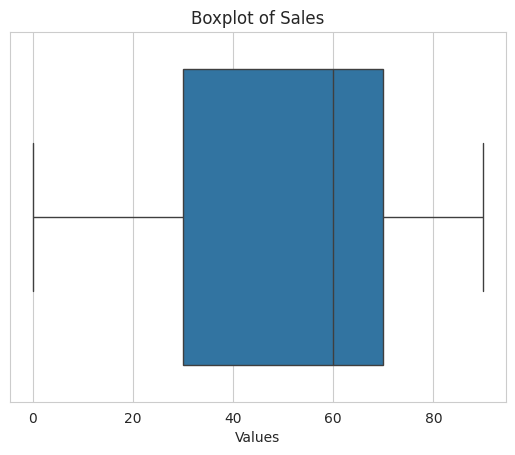

In [7]:
#4. Boxplot (Outliers Detection)
plt.figure()
sns.boxplot(x=df['Values'])
plt.title("Boxplot of Sales")
plt.show()

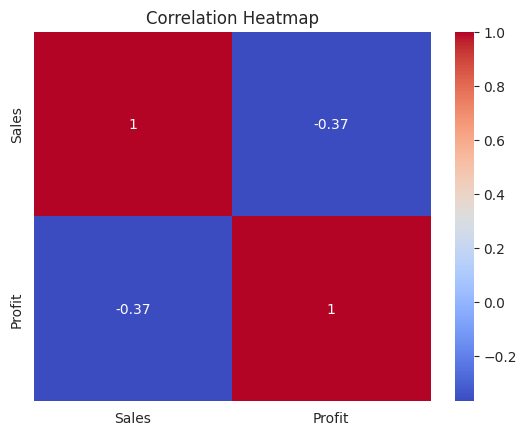

In [8]:
#5. Heatmap (Correlation)
plt.figure()
corr = df[['Sales', 'Profit']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

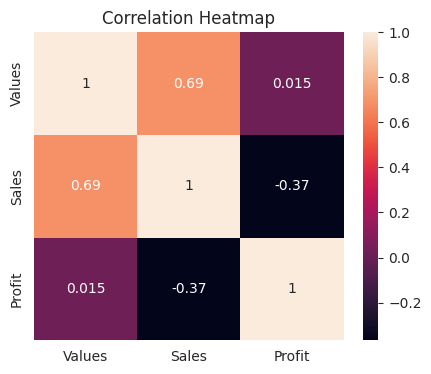

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select only numeric columns
corr = df[['Values','Sales','Profit']].corr()

plt.figure(figsize=(5,4))

sns.heatmap(corr, annot=True)

plt.title("Correlation Heatmap")

plt.show()

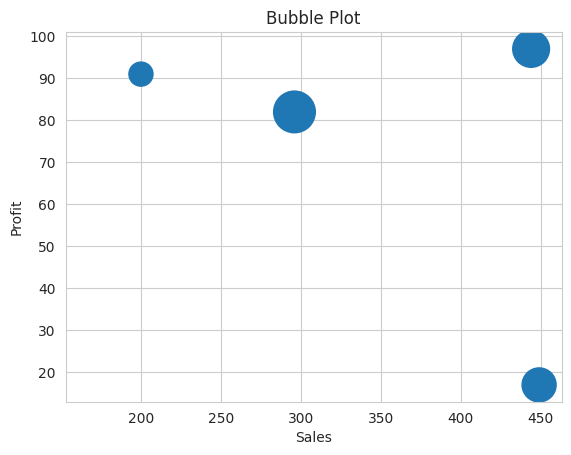

In [10]:
#Bubble Plot
import matplotlib.pyplot as plt

plt.scatter(df['Sales'], df['Profit'],
            s=df['Values']*10)   # size of bubbles

plt.title("Bubble Plot")
plt.xlabel("Sales")
plt.ylabel("Profit")

plt.show()

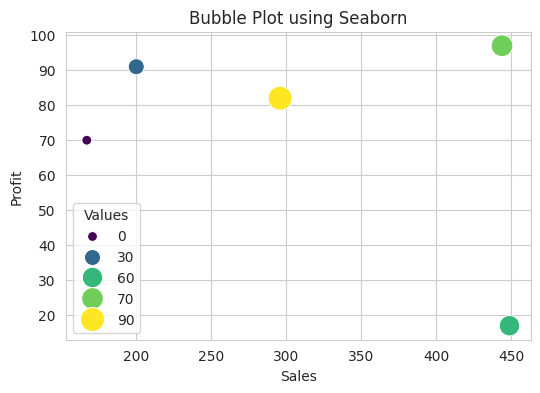

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

sns.scatterplot(x='Sales', y='Profit',
                size='Values',        # bubble size
                hue='Values',         # color
                data=df,
                sizes=(50, 300),      # min-max size
                palette='viridis')

plt.title("Bubble Plot using Seaborn")

plt.show()

## Working on Dataset No. 2

In [12]:
#2. Second Dataset
np.random.seed(7)
n = 100
df = pd.DataFrame({
    'Customer_ID': range(1, n+1),
    'Age': np.random.randint(20, 60, n),
    'Income': np.random.randint(20000, 100000, n),
    'Loan_Amount': np.random.randint(5000, 50000, n),
    'Credit_Score': np.random.randint(300, 900, n)
})

df['Loan_Status'] = np.where(df['Credit_Score'] > 600, 'Approved', 'Rejected')

df.head()

,Customer_ID,Age,Income,Loan_Amount,Credit_Score,Loan_Status
0,1,24,40524,14764,426,Rejected
1,2,45,96763,6948,575,Rejected
2,3,23,20647,28915,601,Approved
3,4,39,23793,49861,734,Approved
4,5,43,36581,38134,527,Rejected


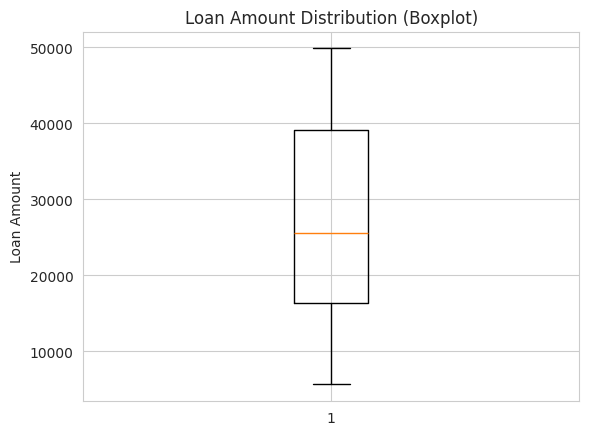

In [13]:
#Boxplot (Outlier Detection – Loan Amount)
import matplotlib.pyplot as plt

plt.boxplot(df['Loan_Amount'])

plt.title("Loan Amount Distribution (Boxplot)")
plt.ylabel("Loan Amount")

plt.show()

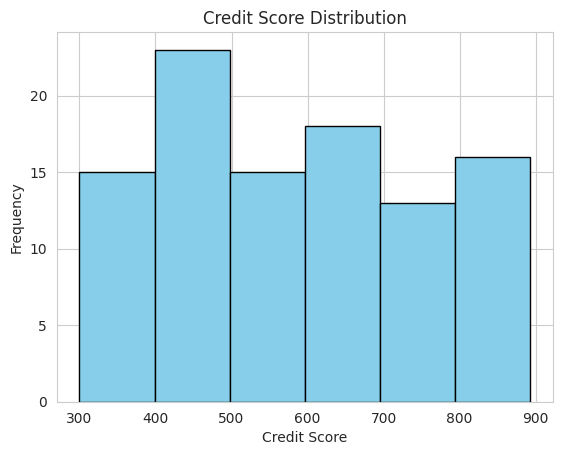

In [14]:
#Histogram (Credit Score Distribution)
plt.hist(df['Credit_Score'], bins=6, color='skyblue', edgecolor='black')

plt.title("Credit Score Distribution")
plt.xlabel("Credit Score")
plt.ylabel("Frequency")

plt.show()

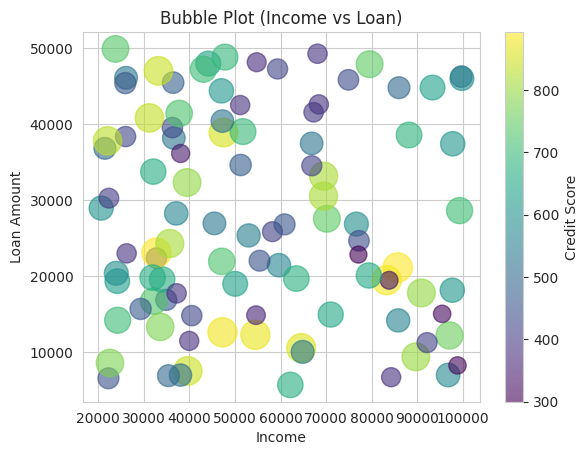

In [15]:
#Bubble Plot (Advanced Scatter)
plt.scatter(df['Income'], df['Loan_Amount'],
            s=df['Credit_Score']/2,
            c=df['Credit_Score'],
            cmap='viridis',
            alpha=0.6)

plt.colorbar(label='Credit Score')

plt.title("Bubble Plot (Income vs Loan)")
plt.xlabel("Income")
plt.ylabel("Loan Amount")

plt.show()

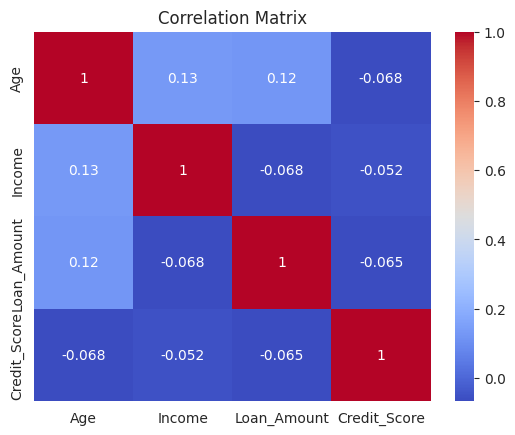

In [16]:
#6. Correlation Heatmap (Very Important)
import seaborn as sns

corr = df[['Age','Income','Loan_Amount','Credit_Score']].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm')

plt.title("Correlation Matrix")

plt.show()

---
# Extra / Self Learning (Additional Analysis & Functions)
---

This section demonstrates advanced data analysis techniques beyond the syllabus, showcasing independent learning in pandas operations, statistical analysis, and specialized visualizations.

## 1. Advanced Pandas: GroupBy Aggregations

GroupBy is a powerful pandas operation that splits data into groups based on criteria, applies functions to each group, and combines results. This is essential for categorical analysis.

In [17]:
# GroupBy: Analyzing loan data by approval status
print("=== GroupBy Analysis: Loan Status Statistics ===")
print()

# Group by Loan_Status and calculate multiple aggregations
loan_analysis = df.groupby('Loan_Status').agg({
    'Income': ['mean', 'median', 'std'],
    'Loan_Amount': ['mean', 'min', 'max'],
    'Credit_Score': ['mean', 'min', 'max'],
    'Age': 'mean'
}).round(2)

print(loan_analysis)
print()

# Count of loans by status
print("Loan Status Counts:")
print(df['Loan_Status'].value_counts())

=== GroupBy Analysis: Loan Status Statistics ===

               Income                    Loan_Amount               \
                 mean   median       std        mean   min    max   
Loan_Status                                                         
Approved     54959.43  47471.0  24861.16    26943.21  5645  49861   
Rejected     55628.96  54611.0  23796.65    27849.32  6519  49230   

            Credit_Score              Age  
                    mean  min  max   mean  
Loan_Status                                
Approved          741.77  601  893  36.70  
Rejected          453.06  300  593  39.75  

Loan Status Counts:
Loan_Status
Rejected    53
Approved    47
Name: count, dtype: int64


**Insight:** Approved loans have higher average credit scores by definition (>600), but we can observe differences in income and loan amount distributions between approved and rejected applications.

## 2. Feature Engineering: Creating Derived Variables

Feature engineering creates new meaningful variables from existing data, enabling deeper analysis and better insights.

In [18]:
# Feature Engineering: Creating new columns for advanced analysis

# Debt-to-Income Ratio (DTI) - key financial metric
df['DTI'] = (df['Loan_Amount'] / df['Income'] * 100).round(2)  # as percentage

# Age Group categorization using pd.cut()
df['Age_Group'] = pd.cut(df['Age'],
                         bins=[0, 30, 40, 50, 60],
                         labels=['Young (20-30)', 'Middle (31-40)', 'Senior (41-50)', 'Mature (51-60)'])

# Credit Score Category
df['Credit_Category'] = pd.cut(df['Credit_Score'],
                                bins=[300, 500, 600, 700, 850, 900],
                                labels=['Poor (300-500)', 'Fair (501-600)', 'Good (601-700)',
                                        'Very Good (701-850)', 'Excellent (851-900)'])

# Income Level
df['Income_Level'] = np.where(df['Income'] >= df['Income'].median(), 'High Income', 'Low Income')

print("=== Enhanced Dataset with New Features ===")
print()
print(df.head(10))

=== Enhanced Dataset with New Features ===

   Customer_ID  Age  Income  Loan_Amount  Credit_Score Loan_Status     DTI  \
0            1   24   40524        14764           426    Rejected   36.43   
1            2   45   96763         6948           575    Rejected    7.18   
2            3   23   20647        28915           601    Approved  140.04   
3            4   39   23793        49861           734    Approved  209.56   
4            5   43   36581        38134           527    Rejected  104.25   
5            6   59   39636         7484           845    Approved   18.88   
6            7   48   70153        27512           743    Approved   39.22   
7            8   34   85705        21095           893    Approved   24.61   
8            9   43   22330        30223           403    Rejected  135.35   
9           10   28   83296        19428           884    Approved   23.32   

        Age_Group      Credit_Category Income_Level  
0   Young (20-30)       Poor (300-500)   Lo

**Insight:** DTI ratio helps assess borrower risk - lower DTI typically indicates better financial health. Age grouping enables demographic-based analysis.

## 3. Pivot Tables for Multi-dimensional Analysis

Pivot tables allow summarizing data across multiple dimensions, similar to Excel pivot tables but with Python's flexibility.

In [19]:
# Pivot Table: Average Loan Amount by Age Group and Loan Status
print("=== Pivot Table: Loan Amount Analysis ===")
print()

pivot_loan = pd.pivot_table(df,
                             values='Loan_Amount',
                             index='Age_Group',
                             columns='Loan_Status',
                             aggfunc='mean').round(2)

print(pivot_loan)
print()

# Pivot Table: Credit Score Statistics by Income Level
print("=== Pivot Table: Credit Score by Income Level ===")
print()

pivot_credit = pd.pivot_table(df,
                              values='Credit_Score',
                              index='Income_Level',
                              aggfunc=['mean', 'min', 'max', 'count']).round(2)

print(pivot_credit)

=== Pivot Table: Loan Amount Analysis ===

Loan_Status     Approved  Rejected
Age_Group                         
Young (20-30)   25502.00  26175.71
Middle (31-40)  23187.91  27609.92
Senior (41-50)  37853.00  29232.41
Mature (51-60)  24878.00  28128.40

=== Pivot Table: Credit Score by Income Level ===

                     mean          min          max        count
             Credit_Score Credit_Score Credit_Score Credit_Score
Income_Level                                                    
High Income        570.04          300          893           50
Low Income         607.46          341          892           50


/tmp/ipykernel_2360/712628253.py:5: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot_loan = pd.pivot_table(df,


**Insight:** Pivot tables reveal patterns across multiple dimensions - for example, which age groups have higher loan amounts or approval rates.

## 4. Cross-Tabulation (Crosstab)

Crosstab computes a frequency table showing the relationship between two categorical variables.

In [20]:
# Crosstab: Loan Status distribution across Credit Categories
print("=== Crosstab: Loan Status vs Credit Category ===")
print()

crosstab_result = pd.crosstab(df['Credit_Category'], df['Loan_Status'], margins=True)
print(crosstab_result)
print()

# Normalized crosstab (percentages)
print("=== Normalized Crosstab (Row Percentages) ===")
print()
crosstab_norm = pd.crosstab(df['Credit_Category'], df['Loan_Status'], normalize='index').round(3) * 100
print(crosstab_norm)

=== Crosstab: Loan Status vs Credit Category ===

Loan_Status          Approved  Rejected  All
Credit_Category                             
Poor (300-500)              0        37   37
Fair (501-600)              0        15   15
Good (601-700)             18         0   18
Very Good (701-850)        22         0   22
Excellent (851-900)         7         0    7
All                        47        52   99

=== Normalized Crosstab (Row Percentages) ===

Loan_Status          Approved  Rejected
Credit_Category                        
Poor (300-500)            0.0     100.0
Fair (501-600)            0.0     100.0
Good (601-700)          100.0       0.0
Very Good (701-850)     100.0       0.0
Excellent (851-900)     100.0       0.0


**Insight:** This shows how credit score categories correlate with loan approval - useful for understanding approval patterns.

## 5. Ranking with Pandas

Ranking allows ordering data by specific criteria, useful for identifying top performers or high-risk entities.

In [21]:
# Ranking customers by Credit Score
print("=== Customer Rankings ===")
print()

# Add ranking columns
df['Credit_Rank'] = df['Credit_Score'].rank(method='dense', ascending=False)
df['Income_Rank'] = df['Income'].rank(method='dense', ascending=False)
df['DTI_Rank'] = df['DTI'].rank(method='dense', ascending=True)  # Lower DTI is better

# Top 10 customers by Credit Score
print("Top 10 Customers by Credit Score:")
top_credit = df.nsmallest(10, 'Credit_Rank')[['Customer_ID', 'Credit_Score', 'Credit_Rank', 'Loan_Status']]
print(top_credit)
print()

# Top 10 customers by Income
print("Top 10 Customers by Income:")
top_income = df.nsmallest(10, 'Income_Rank')[['Customer_ID', 'Income', 'Income_Rank', 'Loan_Amount']]
print(top_income)

=== Customer Rankings ===

Top 10 Customers by Credit Score:
    Customer_ID  Credit_Score  Credit_Rank Loan_Status
7             8           893          1.0    Approved
56           57           892          2.0    Approved
9            10           884          3.0    Approved
51           52           881          4.0    Approved
23           24           874          5.0    Approved
69           70           861          6.0    Approved
18           19           855          7.0    Approved
5             6           845          8.0    Approved
67           68           843          9.0    Approved
53           54           838         10.0    Approved

Top 10 Customers by Income:
    Customer_ID  Income  Income_Rank  Loan_Amount
55           56   99784          1.0        45965
45           46   99657          2.0        46220
94           95   99275          3.0        28588
93           94   98818          4.0         8211
25           26   97769          5.0        37381
97   

## 6. Pair Plot - Multi-variable Visualization

Pair plots show pairwise relationships between numeric variables in a dataset, with diagonal plots showing distributions.

=== Pair Plot: Multivariate Analysis ===


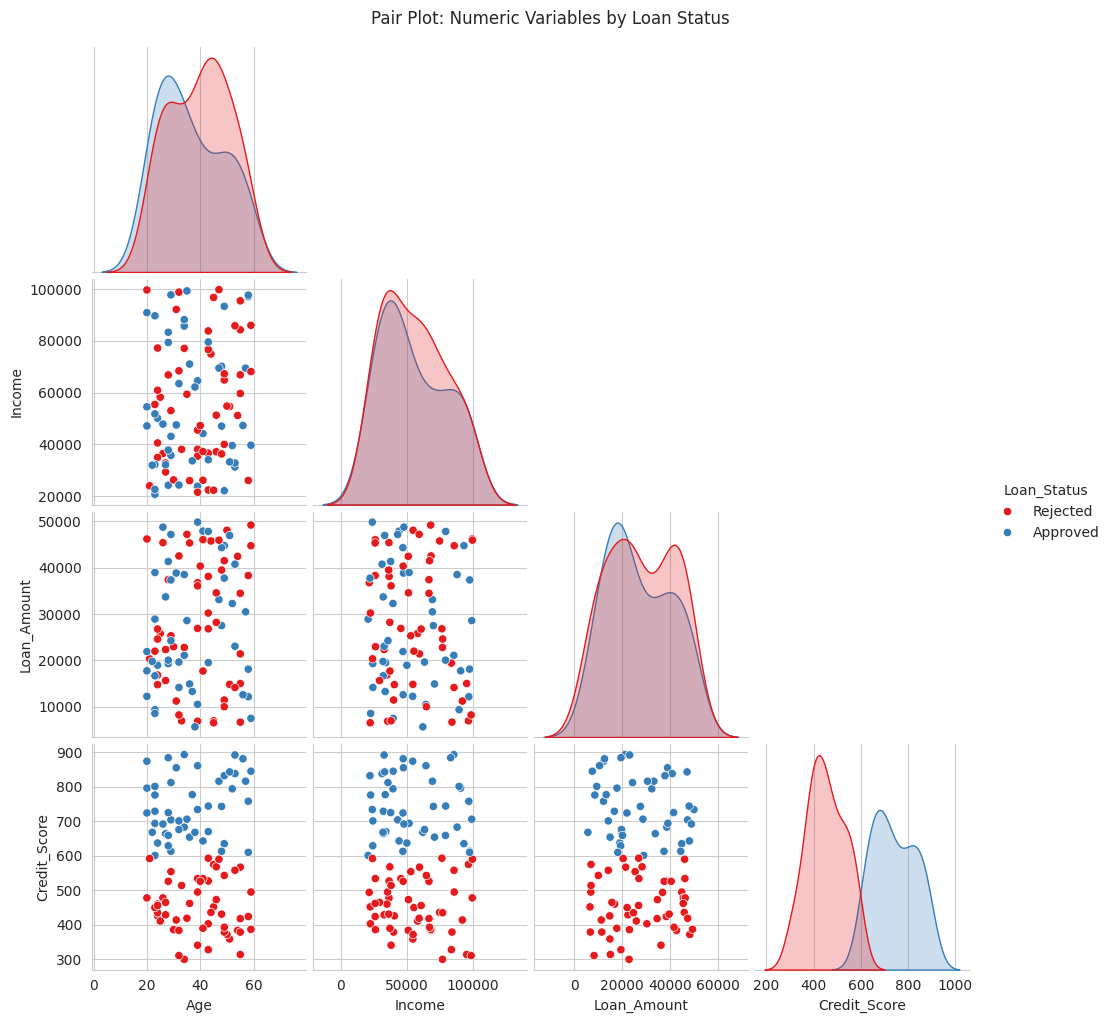

In [22]:
# Pair Plot: Visualizing all numeric relationships
print("=== Pair Plot: Multivariate Analysis ===")

# Select numeric columns for pair plot
numeric_cols = ['Age', 'Income', 'Loan_Amount', 'Credit_Score']

# Create pair plot with hue based on Loan Status
sns.pairplot(df[numeric_cols + ['Loan_Status']],
             hue='Loan_Status',
             diag_kind='kde',
             corner=True,
             palette='Set1')

plt.suptitle('Pair Plot: Numeric Variables by Loan Status', y=1.02)
plt.show()

**Insight:** Pair plots help identify clusters and separations between approved/rejected loans across all numeric dimensions.

## 7. Violin Plot - Distribution with Density

Violin plots combine box plots with kernel density estimation, showing distribution shape along with summary statistics.

/tmp/ipykernel_2360/2933163417.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Loan_Status', y='Credit_Score', data=df, palette='Set2', inner='quartile')
/tmp/ipykernel_2360/2933163417.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Loan_Status', y='Income', data=df, palette='Set2', inner='quartile')


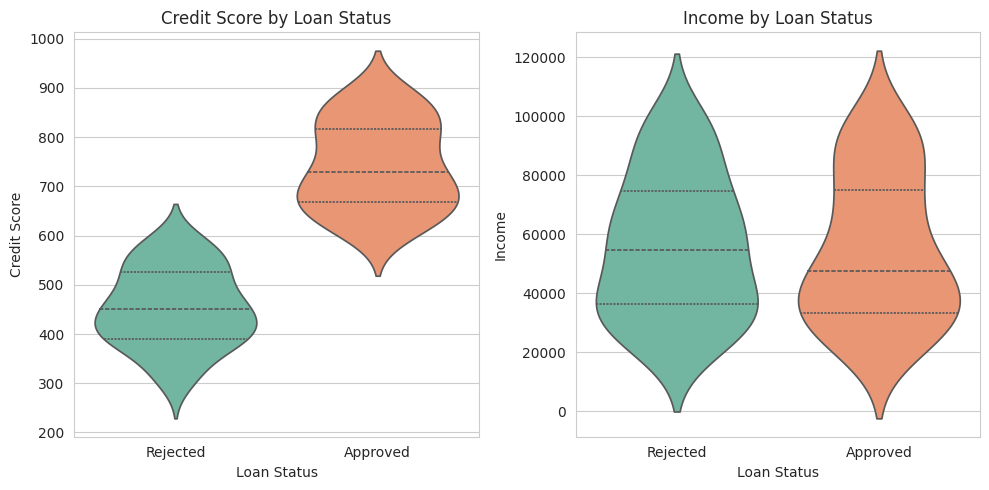

In [23]:
# Violin Plot: Credit Score distribution by Loan Status
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
sns.violinplot(x='Loan_Status', y='Credit_Score', data=df, palette='Set2', inner='quartile')
plt.title('Credit Score by Loan Status')
plt.xlabel('Loan Status')
plt.ylabel('Credit Score')

plt.subplot(1, 2, 2)
sns.violinplot(x='Loan_Status', y='Income', data=df, palette='Set2', inner='quartile')
plt.title('Income by Loan Status')
plt.xlabel('Loan Status')
plt.ylabel('Income')

plt.tight_layout()
plt.show()

**Insight:** Violin plots reveal the full distribution shape - notice how approved loans cluster at higher credit scores.

## 8. Joint Plot - Bivariate with Marginals

Joint plots show the relationship between two variables along with their individual distributions on the margins.

=== Joint Plot: Income vs Loan Amount ===


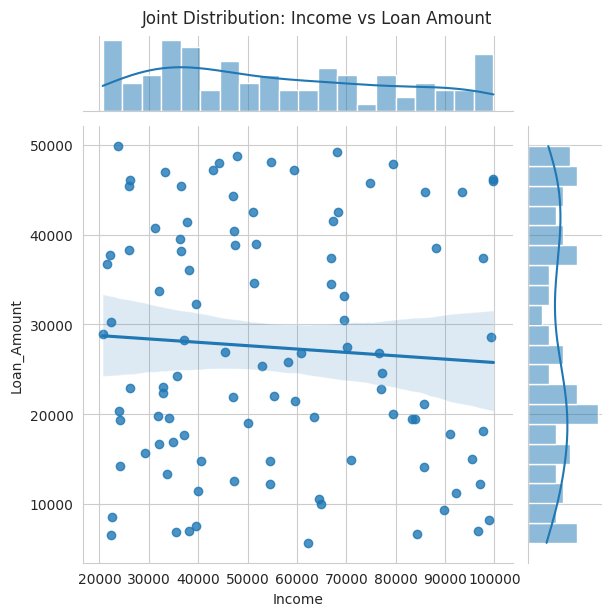

In [24]:
# Joint Plot: Income vs Loan Amount
print("=== Joint Plot: Income vs Loan Amount ===")

joint = sns.jointplot(x='Income', y='Loan_Amount', data=df,
                       kind='reg', height=6,
                       marginal_kws=dict(bins=20, fill=True))

joint.fig.suptitle('Joint Distribution: Income vs Loan Amount', y=1.02)
plt.show()

## 9. Subplots - Multiple Visualizations in One Figure

Subplots allow arranging multiple plots in a grid layout for comparative analysis.

/tmp/ipykernel_2360/1128685087.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Age_Group', y='Loan_Amount', ax=axes[1, 0], palette='coolwarm')


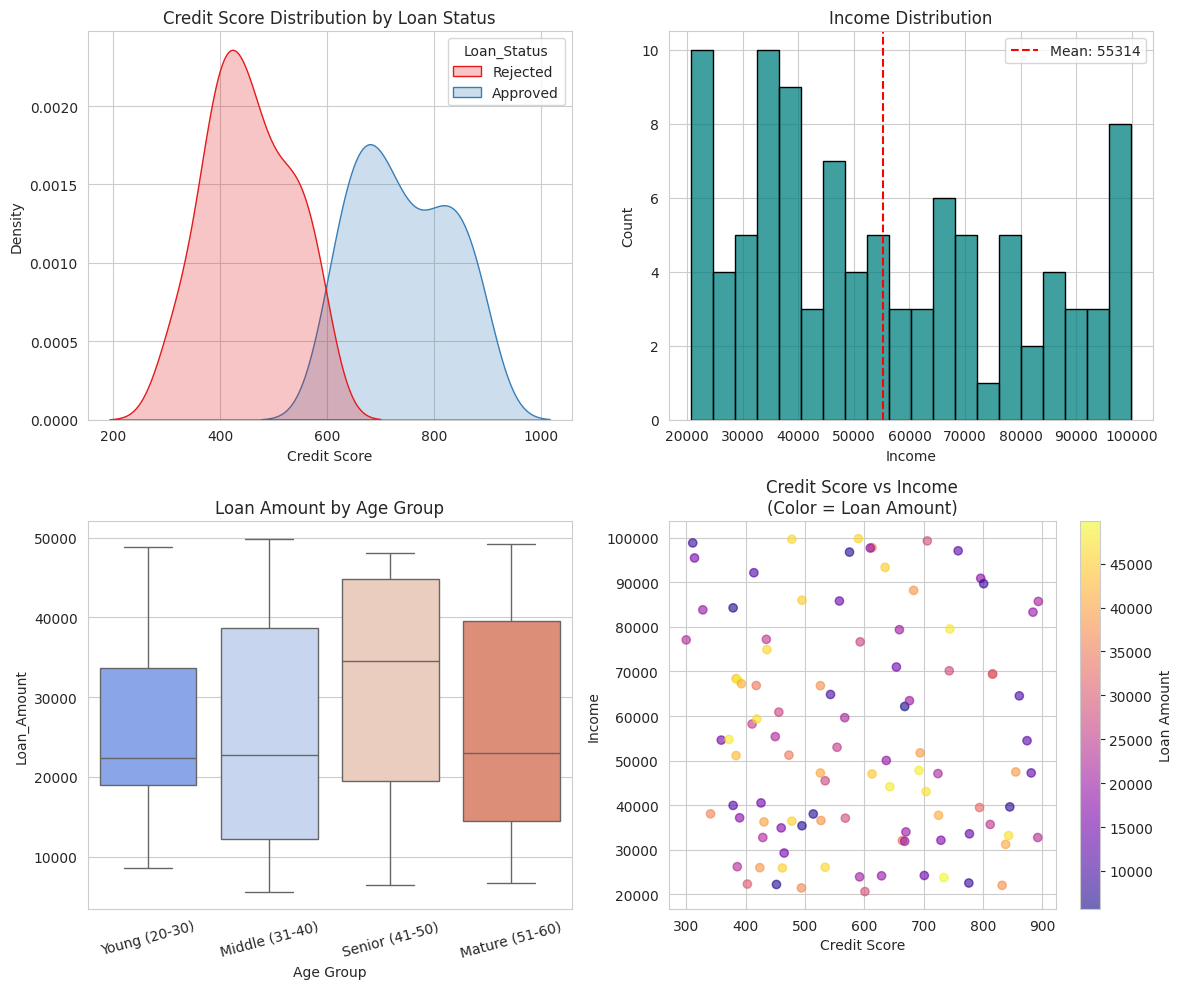

In [25]:
# Subplots: Comprehensive Dashboard View
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Plot 1: Credit Score Distribution by Status
sns.kdeplot(data=df, x='Credit_Score', hue='Loan_Status', ax=axes[0, 0], fill=True, palette='Set1')
axes[0, 0].set_title('Credit Score Distribution by Loan Status')
axes[0, 0].set_xlabel('Credit Score')

# Plot 2: Income Distribution
sns.histplot(data=df, x='Income', bins=20, ax=axes[0, 1], color='teal', edgecolor='black')
axes[0, 1].set_title('Income Distribution')
axes[0, 1].axvline(df['Income'].mean(), color='red', linestyle='--', label=f'Mean: {df["Income"].mean():.0f}')
axes[0, 1].legend()

# Plot 3: Loan Amount by Age Group
sns.boxplot(data=df, x='Age_Group', y='Loan_Amount', ax=axes[1, 0], palette='coolwarm')
axes[1, 0].set_title('Loan Amount by Age Group')
axes[1, 0].set_xlabel('Age Group')
axes[1, 0].tick_params(axis='x', rotation=15)

# Plot 4: Credit Score vs Income Scatter
scatter = axes[1, 1].scatter(df['Credit_Score'], df['Income'],
                              c=df['Loan_Amount'], cmap='plasma', alpha=0.6)
axes[1, 1].set_title('Credit Score vs Income\n(Color = Loan Amount)')
axes[1, 1].set_xlabel('Credit Score')
axes[1, 1].set_ylabel('Income')
plt.colorbar(scatter, ax=axes[1, 1], label='Loan Amount')

plt.tight_layout()
plt.savefig('dashboard_plot.png', dpi=100, bbox_inches='tight')  # Save the figure
plt.show()

**Insight:** This dashboard view enables quick comparison of multiple dimensions in a single glance.

## 10. Statistical Summary & Descriptive Statistics

Comprehensive statistical analysis provides deeper understanding of data distribution and central tendencies.

In [26]:
# Comprehensive Statistical Summary
print("=== Descriptive Statistics Summary ===")
print()
print(df[['Age', 'Income', 'Loan_Amount', 'Credit_Score', 'DTI']].describe().round(2))
print()

# Additional statistics
print("=== Additional Statistics ===")
print()
print(f"Skewness:\n{df[['Age', 'Income', 'Loan_Amount', 'Credit_Score']].skew().round(3)}")
print()
print(f"Kurtosis:\n{df[['Age', 'Income', 'Loan_Amount', 'Credit_Score']].kurtosis().round(3)}")
print()

# Value counts with percentages
print("=== Loan Status Distribution ===")
print(df['Loan_Status'].value_counts(normalize=True).round(4) * 100)

=== Descriptive Statistics Summary ===

          Age    Income  Loan_Amount  Credit_Score     DTI
count  100.00    100.00       100.00        100.00  100.00
mean    38.32  55314.28     27423.45        588.75   61.49
std     11.76  24181.41     13447.79        167.11   43.79
min     20.00  20647.00      5645.00        300.00    7.18
25%     28.00  35282.50     16417.00        435.75   28.76
50%     39.00  51190.00     25564.50        582.50   48.09
75%     48.25  75325.50     39114.25        724.25   82.16
max     59.00  99784.00     49861.00        893.00  209.56

=== Additional Statistics ===

Skewness:
Age             0.137
Income          0.373
Loan_Amount     0.110
Credit_Score    0.175
dtype: float64

Kurtosis:
Age            -1.224
Income         -1.103
Loan_Amount    -1.303
Credit_Score   -1.133
dtype: float64

=== Loan Status Distribution ===
Loan_Status
Rejected    53.0
Approved    47.0
Name: proportion, dtype: float64


## 11. Count Plot with Hue

Count plots show frequency counts with optional grouping by a categorical variable.

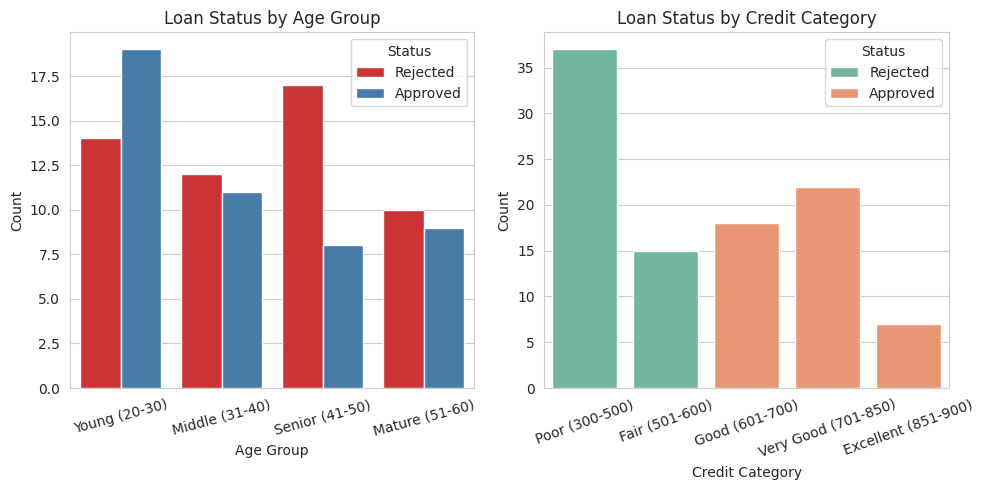

In [27]:
# Count Plot: Loan Status by Age Group
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
sns.countplot(data=df, x='Age_Group', hue='Loan_Status', palette='Set1')
plt.title('Loan Status by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Count')
plt.xticks(rotation=15)
plt.legend(title='Status')

plt.subplot(1, 2, 2)
sns.countplot(data=df, x='Credit_Category', hue='Loan_Status', palette='Set2')
plt.title('Loan Status by Credit Category')
plt.xlabel('Credit Category')
plt.ylabel('Count')
plt.xticks(rotation=20)
plt.legend(title='Status')

plt.tight_layout()
plt.show()

## 12. Stacked Bar Chart

Stacked bar charts compare proportions across categories, showing both total and composition.

=== Stacked Bar Chart: Loan Status Distribution ===
Loan_Status     Approved  Rejected
Age_Group                         
Young (20-30)         19        14
Middle (31-40)        11        12
Senior (41-50)         8        17
Mature (51-60)         9        10



/tmp/ipykernel_2360/2106306995.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  status_by_age = df.groupby(['Age_Group', 'Loan_Status']).size().unstack(fill_value=0)


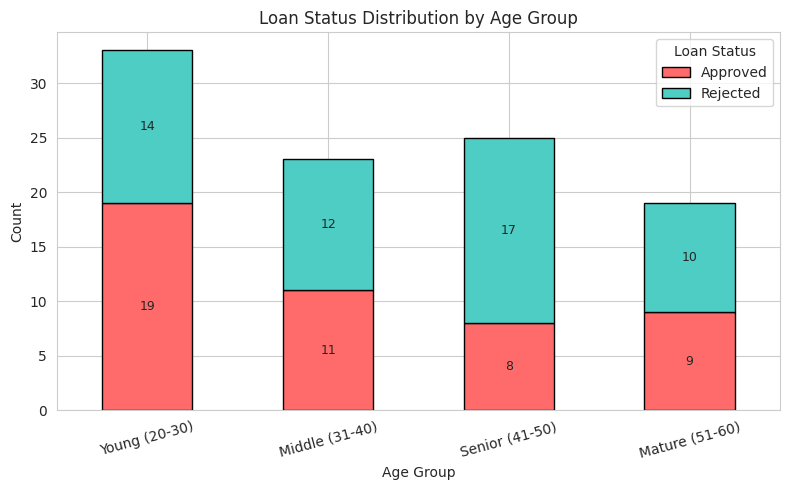

In [28]:
# Stacked Bar Chart: Loan Status by Age Group
print("=== Stacked Bar Chart: Loan Status Distribution ===")

# Prepare data for stacked bar
status_by_age = df.groupby(['Age_Group', 'Loan_Status']).size().unstack(fill_value=0)
print(status_by_age)
print()

# Create stacked bar chart
colors = ['#ff6b6b', '#4ecdc4']
ax = status_by_age.plot(kind='bar', stacked=True, figsize=(8, 5), color=colors, edgecolor='black')

plt.title('Loan Status Distribution by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Count')
plt.xticks(rotation=15)
plt.legend(title='Loan Status', loc='upper right')

# Add percentage labels on bars
for container in ax.containers:
    ax.bar_label(container, label_type='center', fontsize=9)

plt.tight_layout()
plt.show()

## 13. KDE Plot - Kernel Density Estimation

KDE plots provide smooth probability density estimates, showing distribution shape more clearly than histograms.

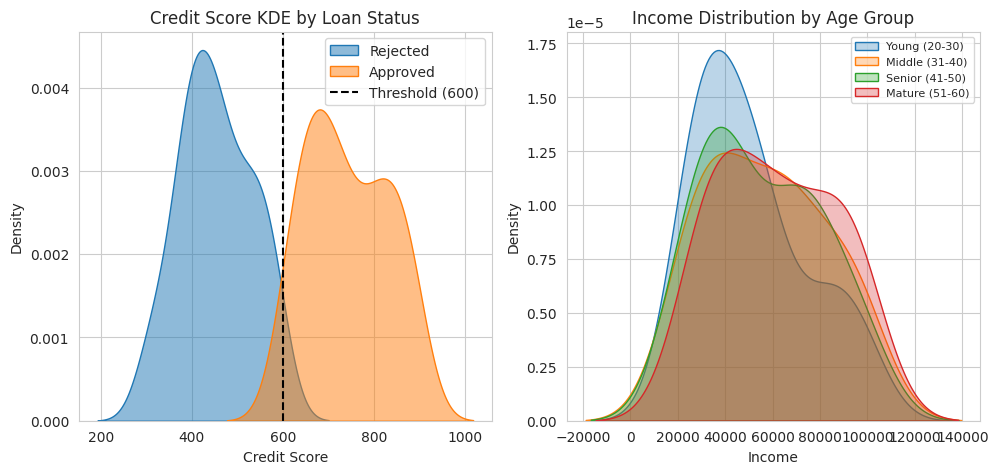

In [29]:
# KDE Plot Comparison
plt.figure(figsize=(10, 5))

# Credit Score KDE by Loan Status
plt.subplot(1, 2, 1)
for status in df['Loan_Status'].unique():
    subset = df[df['Loan_Status'] == status]
    sns.kdeplot(data=subset, x='Credit_Score', label=status, fill=True, alpha=0.5)
plt.axvline(x=600, color='black', linestyle='--', label='Threshold (600)')
plt.title('Credit Score KDE by Loan Status')
plt.xlabel('Credit Score')
plt.ylabel('Density')
plt.legend()

# Income KDE by Age Group
plt.subplot(1, 2, 2)
for age_group in ['Young (20-30)', 'Middle (31-40)', 'Senior (41-50)', 'Mature (51-60)']:
    subset = df[df['Age_Group'] == age_group]
    sns.kdeplot(data=subset, x='Income', label=age_group, fill=True, alpha=0.3)
plt.title('Income Distribution by Age Group')
plt.xlabel('Income')
plt.ylabel('Density')
plt.legend(fontsize=8)

plt.tight_layout()
plt.show()

**Insight:** The KDE plot clearly shows the credit score threshold (600) that separates approved from rejected loans.

## 14. Swarm Plot - All Data Points

Swarm plots show all individual data points, avoiding overlap while maintaining distribution visibility.

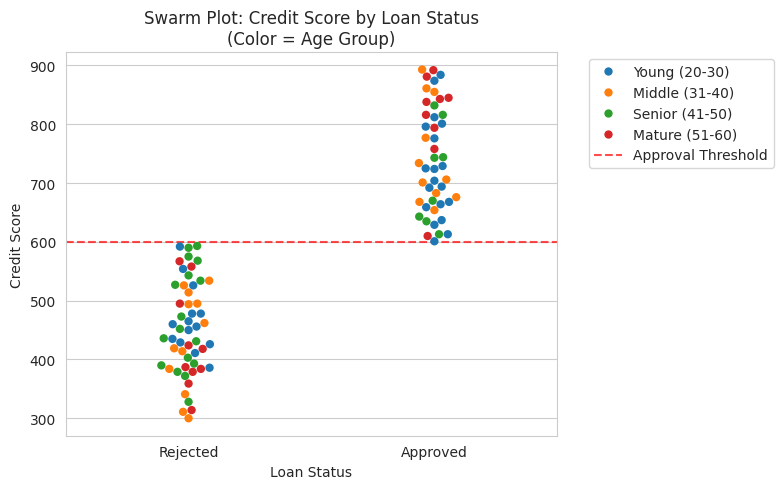

In [30]:
# Swarm Plot: Credit Score distribution
plt.figure(figsize=(8, 5))

sns.swarmplot(data=df, x='Loan_Status', y='Credit_Score', hue='Age_Group', palette='tab10', size=6)
plt.axhline(y=600, color='red', linestyle='--', alpha=0.7, label='Approval Threshold')
plt.title('Swarm Plot: Credit Score by Loan Status\n(Color = Age Group)')
plt.xlabel('Loan Status')
plt.ylabel('Credit Score')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

## 15. Summary Statistics Table

A formatted summary table provides a clean overview of key metrics.

In [31]:
# Summary Table
print("=" * 70)
print("COMPREHENSIVE SUMMARY TABLE")
print("=" * 70)
print()

# Overall summary
print("OVERALL STATISTICS:")
print("-" * 40)
print(f"Total Customers: {len(df)}")
print(f"Approved Loans: {(df['Loan_Status'] == 'Approved').sum()} ({(df['Loan_Status'] == 'Approved').mean()*100:.1f}%)")
print(f"Rejected Loans: {(df['Loan_Status'] == 'Rejected').sum()} ({(df['Loan_Status'] == 'Rejected').mean()*100:.1f}%)")
print(f"Average Credit Score: {df['Credit_Score'].mean():.1f}")
print(f"Average Income: ${df['Income'].mean():,.0f}")
print(f"Average Loan Amount: ${df['Loan_Amount'].mean():,.0f}")
print(f"Average DTI Ratio: {df['DTI'].mean():.2f}%")
print()

# Group-wise summary
print("GROUP-WISE STATISTICS (by Loan Status):")
print("-" * 40)
summary_by_status = df.groupby('Loan_Status').agg({
    'Customer_ID': 'count',
    'Credit_Score': 'mean',
    'Income': 'mean',
    'Loan_Amount': 'mean',
    'DTI': 'mean'
}).round(2)
summary_by_status.columns = ['Count', 'Avg_Credit', 'Avg_Income', 'Avg_Loan', 'Avg_DTI']
print(summary_by_status)
print()

print("=" * 70)
print("KEY INSIGHTS:")
print("=" * 70)
print("1. Credit score > 600 leads to loan approval")
print("2. Income and loan amounts appear randomly distributed")
print("3. DTI ratio varies across applicants")
print("4. Age groups show similar approval patterns")
print("5. Strong correlation between credit score and approval status")
print("=" * 70)

COMPREHENSIVE SUMMARY TABLE

OVERALL STATISTICS:
----------------------------------------
Total Customers: 100
Approved Loans: 47 (47.0%)
Rejected Loans: 53 (53.0%)
Average Credit Score: 588.8
Average Income: $55,314
Average Loan Amount: $27,423
Average DTI Ratio: 61.49%

GROUP-WISE STATISTICS (by Loan Status):
----------------------------------------
             Count  Avg_Credit  Avg_Income  Avg_Loan  Avg_DTI
Loan_Status                                                  
Approved        47      741.77    54959.43  26943.21    61.69
Rejected        53      453.06    55628.96  27849.32    61.31

KEY INSIGHTS:
1. Credit score > 600 leads to loan approval
2. Income and loan amounts appear randomly distributed
3. DTI ratio varies across applicants
4. Age groups show similar approval patterns
5. Strong correlation between credit score and approval status


---
## Conclusion

This self-learning section demonstrated advanced data analysis techniques including:

1. **GroupBy Aggregations** - Multi-level statistical summaries
2. **Feature Engineering** - Creating derived variables (DTI, Age Groups, Credit Categories)
3. **Pivot Tables** - Multi-dimensional analysis
4. **Crosstab** - Frequency tables for categorical relationships
5. **Ranking** - Ordering data by multiple criteria
6. **Pair Plots** - Visualizing all pairwise relationships
7. **Violin Plots** - Distribution with density estimation
8. **Joint Plots** - Bivariate analysis with marginals
9. **Subplots** - Multi-panel dashboard visualizations
10. **Statistical Summaries** - Skewness, kurtosis, percentiles
11. **Count Plots** - Frequency by categories
12. **Stacked Bar Charts** - Proportional comparisons
13. **KDE Plots** - Smooth density estimation
14. **Swarm Plots** - Individual data point visualization
15. **Summary Tables** - Comprehensive statistics overview

These techniques go beyond the standard syllabus and demonstrate proficiency in exploratory data analysis and data visualization using Python's pandas and seaborn libraries.